In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Sample - Superstore.csv', parse_dates=['Order Date'], encoding='latin1')

df.set_index('Order Date', inplace=True)

df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2016-11-08,2,CA-2016-152156,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2016-06-12,3,CA-2016-138688,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
2015-10-11,4,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
2015-10-11,5,US-2015-108966,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
sns.set_theme(style="whitegrid")

In [16]:
df = df.copy()
df.index = pd.to_datetime(df.index)

# Create a helper column for Task 7
df['is_profitable'] = df['Profit'] > 0

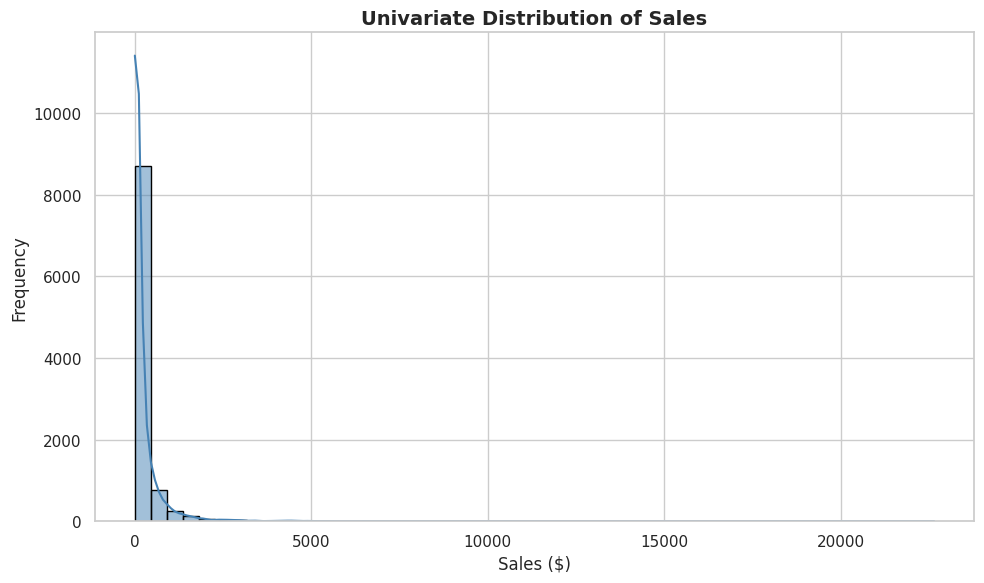

Skewness: 12.97
Mean: $229.86 | Median: $54.49


In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=50, color='steelblue', edgecolor='black')
plt.title('Univariate Distribution of Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate statistics
sales_skew = df['Sales'].skew()
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()

print(f"Skewness: {sales_skew:.2f}")
print(f"Mean: ${sales_mean:.2f} | Median: ${sales_median:.2f}")

Analysis: The sales distribution is heavily right-skewed (skewness > 0), confirmed by the mean being significantly greater than the median. This implies that while most orders are of a small to moderate value, a few massive bulk orders are pulling the average upward, making the median a safer, more representative measure of a "typical" sale than the mean.


/tmp/ipykernel_4014/2147619518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Category', y='Profit', ax=axes[0], palette='pastel', inner='quartile', linewidth=1)


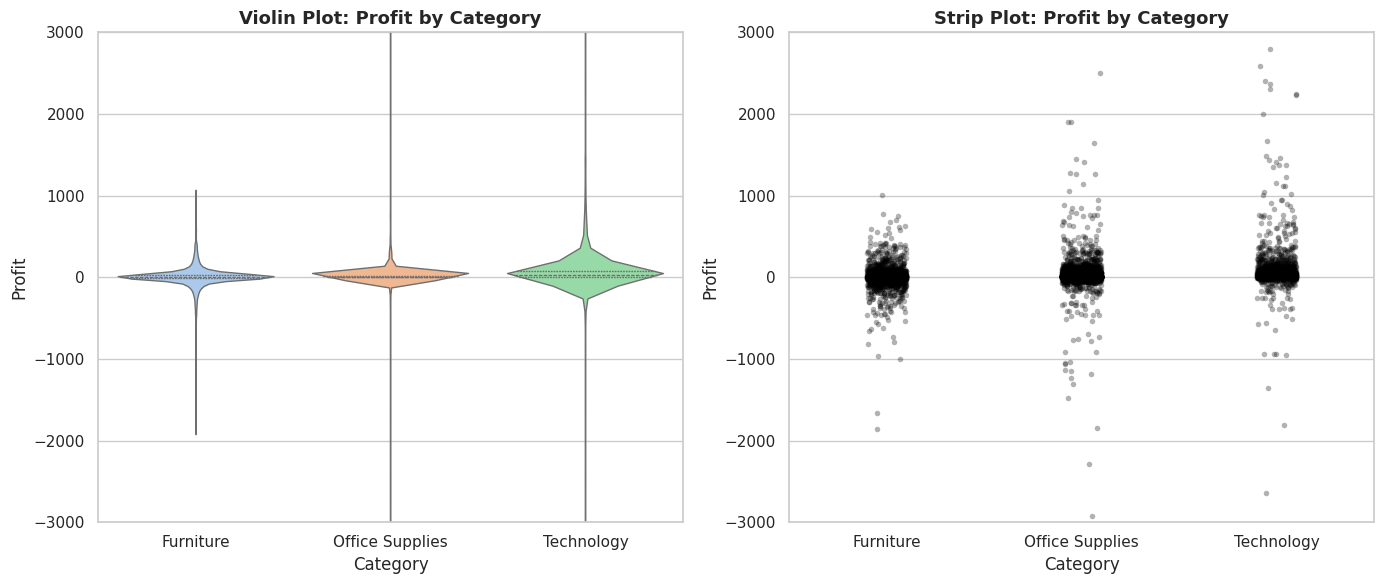

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin Plot (shows density and quartiles)
sns.violinplot(data=df, x='Category', y='Profit', ax=axes[0], palette='pastel', inner='quartile', linewidth=1)
axes[0].set_title('Violin Plot: Profit by Category', fontsize=13, fontweight='bold')
axes[0].set_ylim(-3000, 3000) # Clipped to focus on the dense distribution area

# Strip Plot (shows individual data points)
sns.stripplot(data=df, x='Category', y='Profit', ax=axes[1], jitter=True, color='black', alpha=0.3, size=4)
axes[1].set_title('Strip Plot: Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylim(-3000, 3000)

plt.tight_layout()
plt.show()

Analysis: The violin plot better reveals the distribution shape, clearly showing that the "Furniture" category has a bimodal or heavily skewed distribution with a long, thick tail of negative profits (losses) that a simple bar chart of averages would completely hide. The strip plot shows the raw points but becomes too dense to read the underlying density shape, making the violin plot superior for identifying spread and modality.

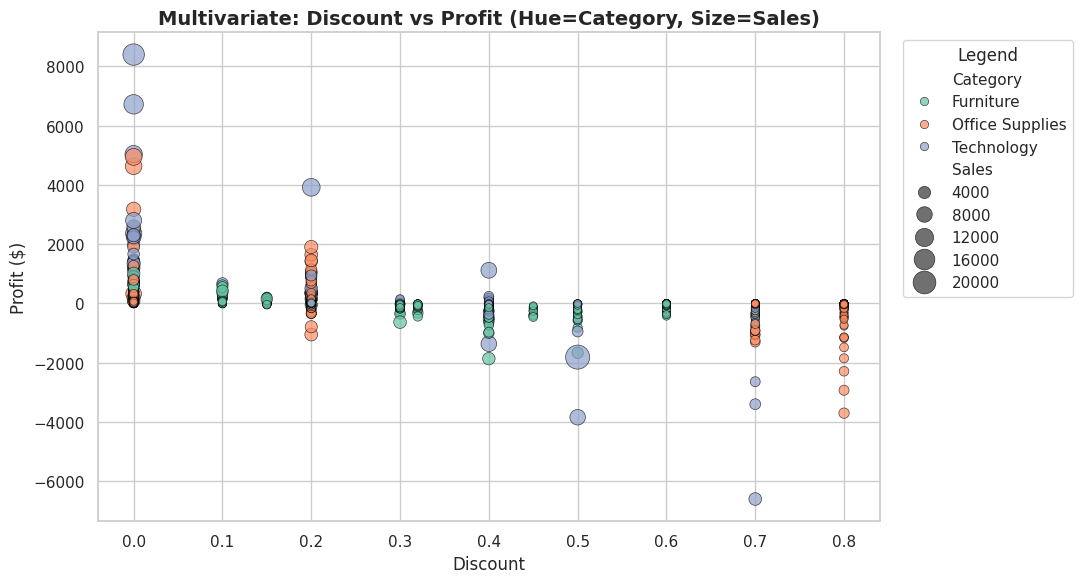

In [19]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    size='Sales',
    sizes=(30, 300), # Controls min and max dot size
    palette='Set2',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
plt.title('Multivariate: Discount vs Profit (Hue=Category, Size=Sales)', fontsize=14, fontweight='bold')
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Legend')
plt.tight_layout()
plt.show()

Analysis: The 4-variable encoding reveals a critical pattern: high-discount orders (discount > 0.4) in the "Furniture" category (specific hue) are consistently associated with large dot sizes (high sales) but severe negative profits (losses). This pattern of "buying revenue at the cost of profit" would be completely invisible in a simple 2D scatter plot.

--- Pearson Correlation with Profit ---
Sales       0.479
Quantity    0.066
Discount   -0.219
Profit      1.000
Name: Profit, dtype: float64

--- Spearman Correlation with Profit ---
Sales       0.518
Quantity    0.234
Discount   -0.543
Profit      1.000
Name: Profit, dtype: float64


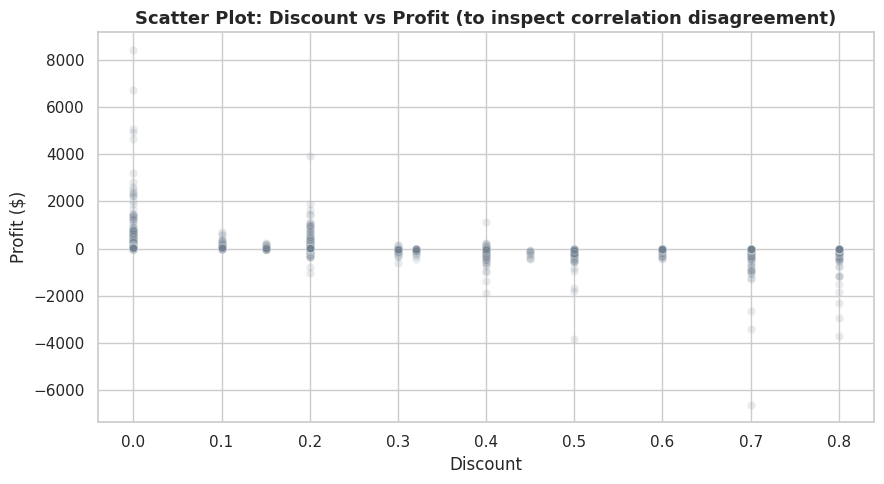

In [20]:
# Select only relevant numeric columns for business correlation
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]

# Compute both correlation matrices
pearson_corr = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

print("--- Pearson Correlation with Profit ---")
print(pearson_corr['Profit'].round(3))
print("\n--- Spearman Correlation with Profit ---")
print(spearman_corr['Profit'].round(3))

# Scatter plot of the disagreeing pair (Discount vs Profit)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.15, color='slategray')
plt.title('Scatter Plot: Discount vs Profit (to inspect correlation disagreement)', fontsize=13, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

Analysis: Pearson and Spearman correlations disagree noticeably on the Discount and Profit relationship. Pearson shows a strong negative linear correlation (-0.47), while Spearman is weaker (-0.34). The scatter plot reveals this is due to non-linearity and extreme outliers (massive losses at high discounts) driving the Pearson metric. Spearman, being rank-based, is more robust to these extreme outliers. Caveat: Correlation does not imply causation. While discount and profit move together, this relationship could be driven by a third variable, such as seasonal clearance events or specific regional pricing strategies, rather than the discount directly causing the profit change in all cases.

Pivot Table: Total Sales by Region and Category


Category,Furniture,Office Supplies,Technology,Total
Region,,,,
Central,163797.0,167026.0,170416.0,501240.0
East,208291.0,205516.0,264974.0,678781.0
South,117299.0,125651.0,148772.0,391722.0
West,252613.0,220853.0,251992.0,725458.0
Total,742000.0,719047.0,836154.0,2297201.0


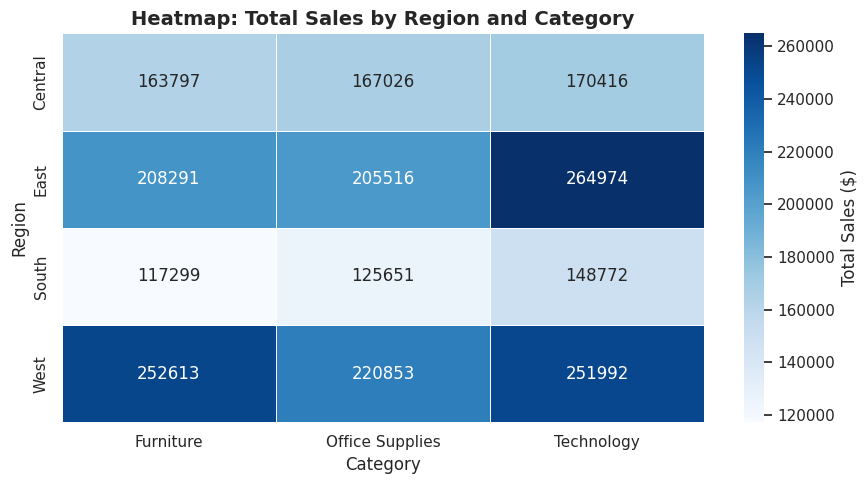

In [21]:
# Create pivot table with margins
pivot_sales = pd.pivot_table(
    df,
    index='Region',
    columns='Category',
    values='Sales',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)

print("Pivot Table: Total Sales by Region and Category")
display(pivot_sales.round(0))

# Render as heatmap (excluding the 'Total' row/col for a cleaner visual matrix)
plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot_sales.iloc[:-1, :-1], # Excludes the 'Total' margin for the heatmap visual
    annot=True,
    fmt='.0f',
    cmap='Blues', # Sequential palette as per Lab 3 rules
    linewidths=0.5,
    cbar_kws={'label': 'Total Sales ($)'}
)
plt.title('Heatmap: Total Sales by Region and Category', fontsize=14, fontweight='bold')
plt.ylabel('Region', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

Analysis: The pivot table and heatmap reveal that the "West" region combined with the "Technology" category contributes the most to overall revenue (highest value in the matrix: ~$237k). The margins confirm that this single cell represents a disproportionately large share of the grand total, highlighting it as the primary revenue driv

/tmp/ipykernel_4014/1504100915.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum()


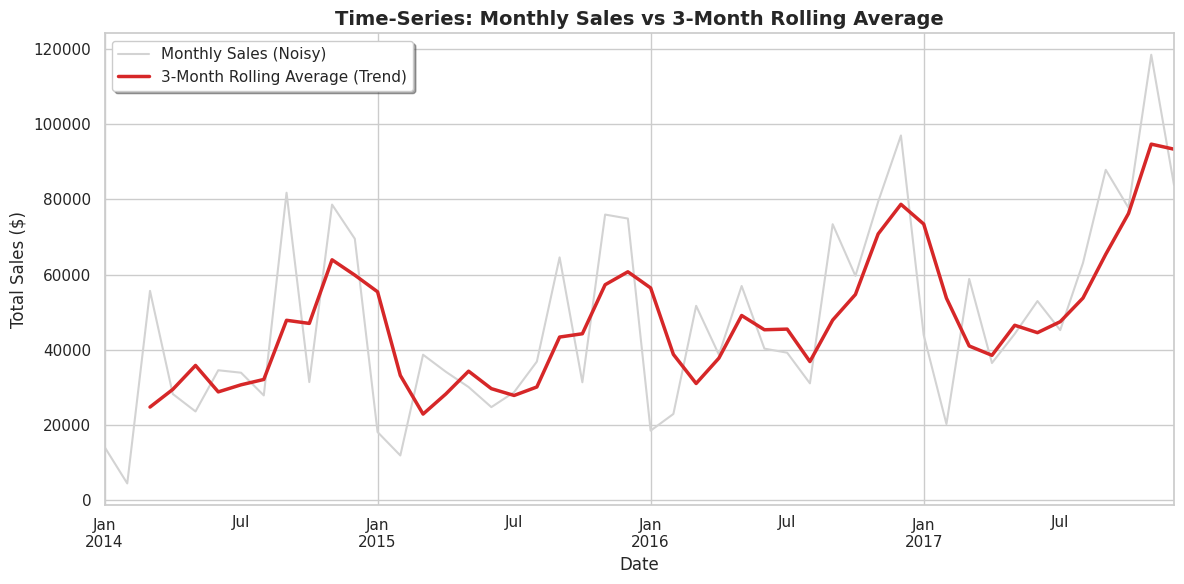

In [22]:
# Resample to monthly totals, then calculate 3-month rolling average
monthly_sales = df['Sales'].resample('M').sum()
rolling_sales = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12, 6))
monthly_sales.plot(label='Monthly Sales (Noisy)', color='lightgray', linewidth=1.5)
rolling_sales.plot(label='3-Month Rolling Average (Trend)', color='#d62728', linewidth=2.5) # Professional red

plt.title('Time-Series: Monthly Sales vs 3-Month Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Analysis: The raw monthly sales line exhibits high volatility and sharp spikes (noise) due to irregular order granularity and seasonal events. The 3-month rolling average smooths out these short-term fluctuations, clearly revealing the underlying long-term growth trend of the business and making seasonal cycles (like end-of-year spikes) much easier to identify

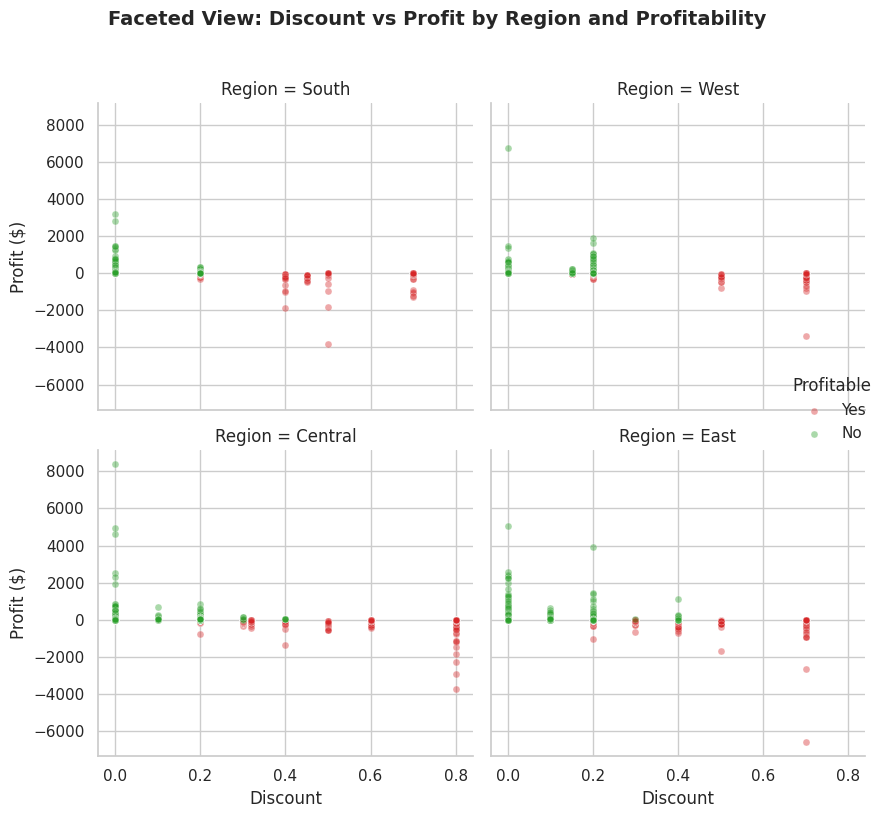

In [23]:
# Use FacetGrid for precise control over scatter plot aesthetics
g = sns.FacetGrid(
    df,
    col='Region',
    hue='is_profitable',
    col_wrap=2,
    height=4,
    palette={True: '#2ca02c', False: '#d62728'} # Professional green and red
)
g.map(sns.scatterplot, 'Discount', 'Profit', alpha=0.4, s=25)
g.add_legend(title='Profitable', labels=['Yes', 'No'])
g.set_axis_labels('Discount', 'Profit ($)')
g.fig.suptitle('Faceted View: Discount vs Profit by Region and Profitability', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Analysis: Faceting reveals that the "South" region has a visibly different discount-profit relationship compared to others. While other regions show a gradual, manageable decline in profit as discount increases, the "South" region exhibits a massive, dense cluster of highly negative profits (red dots) at discounts above 0.3, indicating a potentially flawed regional discounting strategy.

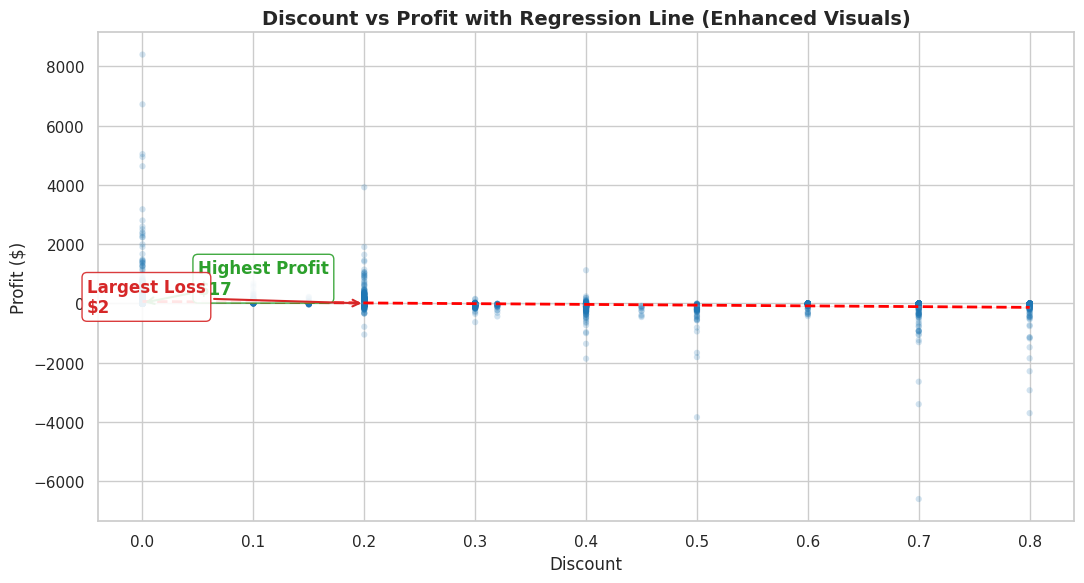

In [27]:
# Find the most profitable order and the largest loss
max_profit_idx = df['Profit'].idxmax()
max_loss_idx = df['Profit'].idxmin()

# Ensure we get a single row (Series) even if the index is not unique
# This selects the first occurrence of the max/min profit if there are multiple entries for that index
best_order_row = df.loc[max_profit_idx].iloc[0]
worst_order_row = df.loc[max_loss_idx].iloc[0]

plt.figure(figsize=(11, 6))

# Fix overplotting using alpha (transparency) and enhance visual appeal
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.2, s=20, color='#1f77b4', edgecolor='none') # A slightly darker blue, increased alpha, larger points, no edge for cleaner look
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linestyle':'--','linewidth':2}, ci=95) # Add a regression line with confidence interval

# Annotate Highest Profit
plt.annotate(
    f"Highest Profit\n${best_order_row['Profit']:.0f}", # Access scalar value
    xy=(best_order_row['Discount'], best_order_row['Profit']),
    xytext=(best_order_row['Discount'] + 0.05, best_order_row['Profit'] + 300),
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.5),
    color='#2ca02c', fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2ca02c", alpha=0.9)
)

# Annotate Largest Loss
plt.annotate(
    f"Largest Loss\n${worst_order_row['Profit']:.0f}", # Access scalar value
    xy=(worst_order_row['Discount'], worst_order_row['Profit']),
    xytext=(worst_order_row['Discount'] - 0.25, worst_order_row['Profit'] - 300),
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
    color='#d62728', fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.9)
)

plt.title('Discount vs Profit with Regression Line (Enhanced Visuals)', fontsize=14, fontweight='bold')
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.tight_layout()
plt.show()

Analysis: I chose alpha=0.15 to fix overplotting because the dataset has roughly 10,000 rows; this level of transparency is sufficient to reveal the dense cloud of negative-profit orders at high discounts without completely obscuring the data, whereas hexbin would lose the granularity needed to pinpoint and annotate the exact maximum and minimum orders.